<a href="https://colab.research.google.com/github/abdullah-621/pandas/blob/main/Merging_Joining__Concatenating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
courses = pd.read_csv("/content/courses.csv")
students = pd.read_csv("/content/students.csv")
nov = pd.read_csv("/content/reg-month1.csv")
des = pd.read_csv("/content/reg-month1.csv")

matches = pd.read_csv("/content/matches.csv")
delivaries = pd.read_csv("/content/deliveries.csv")

In [ ]:
# pd.concate

regs = pd.concat([nov, des], ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [ ]:
mult = pd.concat([nov, des], keys=['Nov', 'Des'])
mult.loc['Nov']
mult.loc[('Des',5)]

,Des
,5
student_id,18
course_id,1


In [ ]:
pd.concat([nov, des], axis=1)

,student_id,course_id,student_id,course_id
0,23,1,23,1
1,15,5,15,5
2,18,6,18,6
3,23,4,23,4
4,16,9,16,9
5,18,1,18,1
6,1,1,1,1
7,7,8,7,8
8,22,3,22,3
9,15,1,15,1


In [ ]:
des

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [ ]:
# inner join
students.merge(regs, how="inner", on= 'student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,1
3,1,Kailash Harjo,23,6
4,3,Parveen Bhalla,3,3
5,3,Parveen Bhalla,3,3
6,7,Tarun Thaker,9,8
7,7,Tarun Thaker,9,10
8,7,Tarun Thaker,9,8
9,7,Tarun Thaker,9,10


In [ ]:
# find total revenue
regs.merge(courses, how='inner', on='course_id')['price'].sum()

np.int64(178350)

In [ ]:
# find month by month revenue

temp_df = pd.concat([nov, des], keys = ['nov', 'des']).reset_index()
temp_df.merge(courses, on='course_id').groupby('level_0')['price'].sum()

,price
level_0,
des,89175
nov,89175


In [ ]:
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [ ]:
# print the regestration table
# cols => name => course => price

cour = regs.merge(students, on='student_id').merge(courses,on='course_id')[['name', 'course_name', 'price']]
cour

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

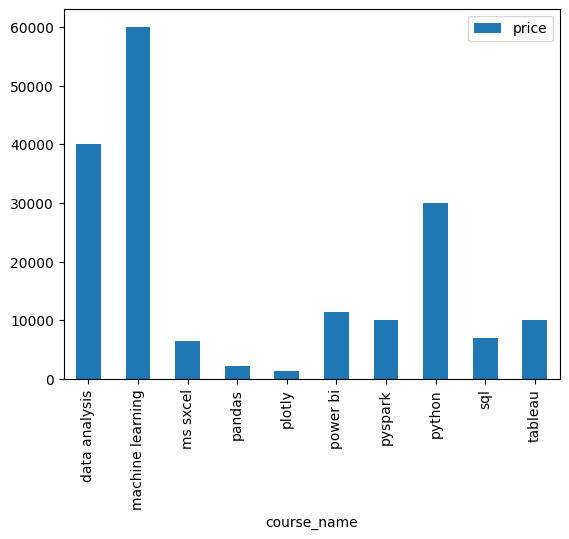

In [ ]:
# plot bar chart by course/revenue

cour.groupby('course_name').sum(numeric_only=True).plot(kind='bar')

In [ ]:
# find common student id nov and des
common_std_id = np.intersect1d(nov['student_id'],des['student_id'])
common_std_id

array([ 1,  3,  7, 11, 13, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25])

In [ ]:
students[students['student_id'].isin(common_std_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
12,13,Munni Varghese,24
14,15,Preet Sha,16
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
18,19,Qabeel Raman,12


In [ ]:
temp_course = regs.merge(courses, how='left', on='course_id').groupby('course_name').sum(numeric_only=True)
courses.isin(temp_course)

,course_id,course_name,price
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [ ]:
temp_df = np.setdiff1d(courses['course_id'], regs['course_id'])
courses[courses['course_id'].isin(temp_df)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [ ]:
courses['course_id']

,course_id
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
regs['course_id']

,course_id
0,1
1,5
2,6
3,4
4,9
5,1
6,1
7,8
8,3
9,1


In [ ]:
# print student name -> partner

students.merge(students, how='inner', left_on='partner', right_on = 'student_id')[['name_x', 'name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [ ]:
# top 3 students who enroll most of the courses
regs.merge(students, on='student_id').groupby(['student_id', 'name'])['name'].count().sort_values(ascending=False).head(3)

,,name
student_id,name,
23,Chhavi Lachman,8
7,Tarun Thaker,4
1,Kailash Harjo,4


In [ ]:
regs.merge(students, on = 'student_id').merge(courses, on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

,,price
student_id,name,
23,Chhavi Lachman,38792
19,Qabeel Raman,26996
24,Radhika Suri,19998


In [ ]:
delivaries

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,1.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,2.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,3.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,4.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,5.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10218,44,1,Mumbai Indians,Delhi Daredevils,4.0,4.0,LMP Simmons,PA Patel,K Rabada,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,NaN,NaN,NaN
10219,44,1,Mumbai Indians,Delhi Daredevils,4.0,5.0,LMP Simmons,PA Patel,K Rabada,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
10220,44,1,Mumbai Indians,Delhi Daredevils,4.0,6.0,LMP Simmons,PA Patel,K Rabada,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN
10221,44,1,Mumbai Indians,Delhi Daredevils,5.0,1.0,LMP Simmons,PA Patel,Z Khan,0.0,...,0.0,0.0,0.0,0.0,6.0,0.0,6.0,NaN,NaN,NaN


In [124]:
# find top 3 studium with highest sixes/match ratio

# ipl = pd.merge(delivaries,matches, how='inner',left_on='match_id',right_on='id')
ipl = delivaries.merge(matches,left_on='match_id',right_on='id')
six_df = ipl[ipl['batsman_runs'] == 6]


In [125]:
num_sixs = six_df.groupby('venue')['venue'].count()

In [126]:
num_match = matches['venue'].value_counts()


In [130]:
(num_sixs / num_match).sort_values(ascending=False).head(3)

,0
venue,
Holkar Cricket Stadium,12.0
Saurashtra Cricket Association Stadium,7.3
Maharashtra Cricket Association Stadium,5.0


In [137]:
# find per season orange cap holder
temp_df = delivaries.merge(matches, left_on='match_id',right_on='id')
temp_df['season'].value_counts()

,count
season,
2017,10223
